# 🍽️ Zomato Restaurant Data Analysis Project

### A Complete Exploratory Data Analysis using Pandas, Matplotlib & Seaborn

---

## 1. Project Objective

**Project Title:** Zomato Restaurant Data Analysis Understanding Restaurant Trends, Ratings, Cost and Customer Engagement,

**Objective:**
The goal of this project is to analyze the Zomato restaurant dataset to uncover meaningful business insights about restaurant distribution, pricing, cuisines, customer ratings, and the impact of online ordering and table booking facilities. The project uses **only Pandas** for data manipulation and cleaning, and **only Matplotlib and Seaborn** for visualization.

**Dataset Overview:**
The dataset contains **9,551 restaurant records** across **141 cities** and **15 countries**, with **17 columns** describing restaurant identity, location, cuisine, pricing, service facilities, customer votes, and ratings. The data is heavily concentrated in India (~90% of records — mainly New Delhi, Gurgaon, Noida and Faridabad), so several location-based insights are naturally India-centric, which is called out explicitly wherever relevant.

**Column Descriptions:**

| Column | Description |
|---|---|
| `RestaurantID` | Unique identifier for each restaurant |
| `RestaurantName` | Name of the restaurant |
| `CountryCode` | Numeric code identifying the country |
| `City` | City where the restaurant is located |
| `Address` | Full street address |
| `Locality` | Neighborhood / locality name |
| `LocalityVerbose` | Locality plus city, more descriptive |
| `Cuisines` | Pipe-separated list of cuisines served (used as the closest available proxy for "restaurant type", since no dedicated restaurant-type column exists in this dataset) |
| `Currency` | Currency used for pricing in that country |
| `Has_Table_booking` | Whether the restaurant offers table booking (Yes/No) |
| `Has_Online_delivery` | Whether the restaurant offers online delivery (Yes/No) |
| `Is_delivering_now` | Whether the restaurant is currently delivering (Yes/No) |
| `Switch_to_order_menu` | Whether an order-menu switch feature is available (Yes/No) |
| `Price_range` | Price category from 1 (cheapest) to 4 (most expensive) |
| `Votes` | Number of user votes/reviews received |
| `Average_Cost_for_two` | Approximate cost for two people, in local currency |
| `Rating` | Aggregate customer rating (1.0 – 4.9) |

**Business Questions to be Answered:**
1. Which cuisine/type of restaurant is most common?
2. Which locations have the highest number of restaurants?
3. What is the distribution of restaurant ratings?
4. Which cuisines have the highest average rating?
5. Which cuisines have the highest average cost?
6. Which restaurants receive the highest number of votes?
7. Is there a relationship between ratings and votes?
8. Is there a relationship between cost and ratings?
9. Does online ordering affect restaurant ratings?
10. Which cuisines are most popular (by vote volume)?
11. Which locations have the highest-rated restaurants?
12. Which cuisines/categories are most common (deep dive)?
13. What is the distribution of restaurant costs?
14. Which restaurants are the most popular based on votes?
15. What are the most important business insights from the dataset?


## 2. Setup — Importing Libraries and Loading Data

As required, we use **only Pandas, Matplotlib and Seaborn**.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

In [3]:
# read_csv() - load the dataset
df=pd.read_csv("Zomato_Dataset - Zomato_Dataset.csv")
print(df)

      RestaurantID            RestaurantName  CountryCode              City  \
0          6317637          Le Petit Souffle          162       Makati City   
1          6304287          Izakaya Kikufuji          162       Makati City   
2          6300002    Heat - Edsa Shangri-La          162  Mandaluyong City   
3          6318506                      Ooma          162  Mandaluyong City   
4          6314302               Sambo Kojin          162  Mandaluyong City   
...            ...                       ...          ...               ...   
9546       5915730               Naml? Gurme          208          ?stanbul   
9547       5908749               Ceviz A?ac?          208          ?stanbul   
9548       5915807                     Huqqa          208          ?stanbul   
9549       5916112                A??k Kahve          208          ?stanbul   
9550       5927402  Walter's Coffee Roastery          208          ?stanbul   

                                                Add

### 2.1 First Look at the Data

In [57]:
# head(), tail(), sample()
df.head()


,RestaurantID,RestaurantName,CountryCode,City,Address,Locality,LocalityVerbose,Cuisines,Currency,Has_Table_booking,Has_Online_delivery,Is_delivering_now,Switch_to_order_menu,Price_range,Votes,Average_Cost_for_two,Rating
0,6317637,Le Petit Souffle,162,Makati City,Third Floor| Century City Mall| Kalayaan Avenu...,Century City Mall| Poblacion| Makati City,Century City Mall| Poblacion| Makati City| Mak...,French| Japanese| Desserts,Botswana Pula(P),Yes,No,No,No,3,314,1100,4.8
1,6304287,Izakaya Kikufuji,162,Makati City,Little Tokyo| 2277 Chino Roces Avenue| Legaspi...,Little Tokyo| Legaspi Village| Makati City,Little Tokyo| Legaspi Village| Makati City| Ma...,Japanese,Botswana Pula(P),Yes,No,No,No,3,591,1200,4.5
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,Edsa Shangri-La| 1 Garden Way| Ortigas| Mandal...,Edsa Shangri-La| Ortigas| Mandaluyong City,Edsa Shangri-La| Ortigas| Mandaluyong City| Ma...,Seafood| Asian| Filipino| Indian,Botswana Pula(P),Yes,No,No,No,4,270,4000,4.4
3,6318506,Ooma,162,Mandaluyong City,Third Floor| Mega Fashion Hall| SM Megamall| O...,SM Megamall| Ortigas| Mandaluyong City,SM Megamall| Ortigas| Mandaluyong City| Mandal...,Japanese| Sushi,Botswana Pula(P),No,No,No,No,4,365,1500,4.9
4,6314302,Sambo Kojin,162,Mandaluyong City,Third Floor| Mega Atrium| SM Megamall| Ortigas...,SM Megamall| Ortigas| Mandaluyong City,SM Megamall| Ortigas| Mandaluyong City| Mandal...,Japanese| Korean,Botswana Pula(P),Yes,No,No,No,4,229,1500,4.8


In [58]:
df.tail()

,RestaurantID,RestaurantName,CountryCode,City,Address,Locality,LocalityVerbose,Cuisines,Currency,Has_Table_booking,Has_Online_delivery,Is_delivering_now,Switch_to_order_menu,Price_range,Votes,Average_Cost_for_two,Rating
9546,5915730,Naml? Gurme,208,?stanbul,Kemanke? Karamustafa Pa?a Mahallesi| R?ht?m Ca...,Karak?y,Karak?y| ?stanbul,Turkish,Turkish Lira(TL),No,No,No,No,3,788,80,4.1
9547,5908749,Ceviz A?ac?,208,?stanbul,Ko?uyolu Mahallesi| Muhittin ?st?nda? Caddesi|...,Ko?uyolu,Ko?uyolu| ?stanbul,World Cuisine| Patisserie| Cafe,Turkish Lira(TL),No,No,No,No,3,1034,105,4.2
9548,5915807,Huqqa,208,?stanbul,Kuru?e?me Mahallesi| Muallim Naci Caddesi| No ...,Kuru?e?me,Kuru?e?me| ?stanbul,Italian| World Cuisine,Turkish Lira(TL),No,No,No,No,4,661,170,3.7
9549,5916112,A??k Kahve,208,?stanbul,Kuru?e?me Mahallesi| Muallim Naci Caddesi| No ...,Kuru?e?me,Kuru?e?me| ?stanbul,Restaurant Cafe,Turkish Lira(TL),No,No,No,No,4,901,120,4.0
9550,5927402,Walter's Coffee Roastery,208,?stanbul,Cafea?a Mahallesi| Bademalt? Sokak| No 21/B| K...,Moda,Moda| ?stanbul,Cafe,Turkish Lira(TL),No,No,No,No,2,591,55,4.0


In [59]:
# 5 random rows select (seed fix = 42)
df.sample(5, random_state=42)

,RestaurantID,RestaurantName,CountryCode,City,Address,Locality,LocalityVerbose,Cuisines,Currency,Has_Table_booking,Has_Online_delivery,Is_delivering_now,Switch_to_order_menu,Price_range,Votes,Average_Cost_for_two,Rating
4731,3918,Wah Ji Wah,1,New Delhi,B-6/1| Double Story| Near Metro Pillar 371| Ra...,Kirti Nagar,Kirti Nagar| New Delhi,North Indian,Indian Rupees(Rs.),No,No,No,No,1,54,350,2.1
1468,18408054,19 Flavours Biryani,1,Gurgaon,Global Foyer Mall| Sector 43| Golf Course Road...,Global Foyer Mall| Golf Course Road,Global Foyer Mall| Golf Course Road| Gurgaon,Mughlai| Hyderabadi,Indian Rupees(Rs.),No,Yes,No,No,2,84,700,4.1
9037,309693,Andaaz E Paranthas,1,Noida,306| 2nd Floor| Food Court| Spice World Mall| ...,Spice World Mall| Sector 25,Spice World Mall| Sector 25| Noida,North Indian| Mughlai,Indian Rupees(Rs.),No,No,No,No,2,36,550,3.2
7866,18157386,Tony's,1,New Delhi,C-23| Single Storey| Vijay Nagar| New Delhi,Vijay Nagar,Vijay Nagar| New Delhi,Fast Food,Indian Rupees(Rs.),No,Yes,No,No,1,163,200,4.4
5570,18396163,Yummy Adda,1,New Delhi,1333| Near Batra Cinema| Mukherjee Nagar| New ...,Mukherjee Nagar,Mukherjee Nagar| New Delhi,North Indian| Mughlai,Indian Rupees(Rs.),No,No,No,No,1,14,400,3.5


### 2.2 Structural Overview

In [60]:
# shape, columns, index, size
print("Shape (rows, columns):", df.shape)
print("Number of columns:", len(df.columns))
print("Columns:", list(df.columns))

Shape (rows, columns): (9551, 17)
Number of columns: 17
Columns: ['RestaurantID', 'RestaurantName', 'CountryCode', 'City', 'Address', 'Locality', 'LocalityVerbose', 'Cuisines', 'Currency', 'Has_Table_booking', 'Has_Online_delivery', 'Is_delivering_now', 'Switch_to_order_menu', 'Price_range', 'Votes', 'Average_Cost_for_two', 'Rating']


In [61]:
#index, size
print("Index range:", df.index)
print("Total elements (size):", df.size)

Index range: RangeIndex(start=0, stop=9551, step=1)
Total elements (size): 162367


In [62]:
# info() - data types + non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   RestaurantID          9551 non-null   int64  
 1   RestaurantName        9551 non-null   object 
 2   CountryCode           9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   LocalityVerbose       9551 non-null   object 
 7   Cuisines              9542 non-null   object 
 8   Currency              9551 non-null   object 
 9   Has_Table_booking     9551 non-null   object 
 10  Has_Online_delivery   9551 non-null   object 
 11  Is_delivering_now     9551 non-null   object 
 12  Switch_to_order_menu  9551 non-null   object 
 13  Price_range           9551 non-null   int64  
 14  Votes                 9551 non-null   int64  
 15  Average_Cost_for_two 

In [63]:
# describe() - statistical summary of numeric columns
df.describe()

,RestaurantID,CountryCode,Price_range,Votes,Average_Cost_for_two,Rating
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,1.804837,156.909748,1199.210763,2.891268
std,8.791521e+06,56.750546,0.905609,430.169145,16121.183073,1.128845
min,5.300000e+01,1.000000,1.000000,0.000000,0.000000,1.000000
25%,3.019625e+05,1.000000,1.000000,5.000000,250.000000,2.500000
50%,6.004089e+06,1.000000,2.000000,31.000000,400.000000,3.200000
75%,1.835229e+07,1.000000,2.000000,131.000000,700.000000,3.700000
max,1.850065e+07,216.000000,4.000000,10934.000000,800000.000000,4.900000


In [64]:
# describe() for categorical/object columns
df.describe(include='object')

,RestaurantName,City,Address,Locality,LocalityVerbose,Cuisines,Currency,Has_Table_booking,Has_Online_delivery,Is_delivering_now,Switch_to_order_menu
count,9551,9551,9551,9551,9551,9542,9551,9551,9551,9551,9551
unique,7446,141,8918,1208,1265,1825,12,2,2,2,1
top,Cafe Coffee Day,New Delhi,Dilli Haat| INA| New Delhi,Connaught Place,Connaught Place| New Delhi,North Indian,Indian Rupees(Rs.),No,No,No,No
freq,83,5473,11,122,122,936,8652,8393,7100,9517,9551


In [65]:
# dtypes
df.dtypes

RestaurantID              int64
RestaurantName           object
CountryCode               int64
City                     object
Address                  object
Locality                 object
LocalityVerbose          object
Cuisines                 object
Currency                 object
Has_Table_booking        object
Has_Online_delivery      object
Is_delivering_now        object
Switch_to_order_menu     object
Price_range               int64
Votes                     int64
Average_Cost_for_two      int64
Rating                  float64
dtype: object

### 2.3 Unique Values & Value Counts

In [66]:
# value_counts() - frequency of categories
print("Top 10 Cities by restaurant count:")
print(df['City'].value_counts().head(10))
print()
print("Has_Online_delivery distribution:")
print(df['Has_Online_delivery'].value_counts())

Top 10 Cities by restaurant count:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21
Name: count, dtype: int64

Has_Online_delivery distribution:
Has_Online_delivery
No     7100
Yes    2451
Name: count, dtype: int64


In [67]:
# unique() and nunique()
print("Unique countries (CountryCode):", df['CountryCode'].nunique())
print("Unique cities:", df['City'].nunique())
print("Unique currencies:", df['Currency'].unique())
print("Unique Price_range values:", sorted(df['Price_range'].unique()))

Unique countries (CountryCode): 15
Unique cities: 141
Unique currencies: ['Botswana Pula(P)' 'Brazilian Real(R$)' 'Dollar($)' 'Emirati Diram(AED)'
 'Indian Rupees(Rs.)' 'Indonesian Rupiah(IDR)' 'NewZealand($)' 'Pounds(?)'
 'Qatari Rial(QR)' 'Rand(R)' 'Sri Lankan Rupee(LKR)' 'Turkish Lira(TL)']
Unique Price_range values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## 3. Data Cleaning Using Pandas

We now perform a full cleaning pass: missing values, duplicates, data types, inconsistent categories, outliers and derived columns. We record the "before" state so the effect of cleaning is visible.

### 3.1 Missing Value Analysis

In [68]:
# isnull() / notnull()
print("Missing values per column (BEFORE cleaning):")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("Rows with a non-null Cuisines value:",df['Cuisines'].notnull().sum())

Missing values per column (BEFORE cleaning):
Cuisines    9
dtype: int64

Rows with a non-null Cuisines value: 9542


In [69]:
# Inspect the rows with missing Cuisines
df[df['Cuisines'].isnull()][['RestaurantID', 'RestaurantName', 'City']]

,RestaurantID,RestaurantName,City
84,17284105,Cookie Shoppe,Albany
87,17284211,Pearly's Famous Country Cookng,Albany
94,17284158,Jimmie's Hot Dogs,Albany
297,17374552,Corkscrew Cafe,Gainesville
328,17501439,Dovetail,Macon
346,17606621,HI Lite Bar & Lounge,Miller
368,17059060,Hillstone,Orlando
418,17142698,Leonard's Bakery,Rest of Hawaii
455,17616465,Tybee Island Social Club,Savannah


In [70]:
# fillna() - only Cuisines has nulls (9 rows); fill with a clear placeholder
# rather than dropping, since these are still valid restaurant records

df['Cuisines'] = df['Cuisines'].fillna('Not Specified')
print("Missing values AFTER fillna():")
print(df.isnull().sum().sum(), "total missing values remain")

Missing values AFTER fillna():
0 total missing values remain


In [71]:
# dropna() - demonstration only 
rows_before = len(df)
demo_dropna = df.dropna()
print(f"Rows before dropna(): {rows_before}")
print(f"Rows after dropna(): {len(demo_dropna)}")

Rows before dropna(): 9551
Rows after dropna(): 9551


### 3.2 Duplicate Value Analysis

In [72]:
# duplicated() / drop_duplicates()
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate RestaurantIDs:", df['RestaurantID'].duplicated().sum())

Fully duplicated rows: 0
Duplicate RestaurantIDs: 0


In [73]:
# Apply drop_duplicates() 
before = len(df)
df = df.drop_duplicates()
print(f"Rows before: {before} | Rows after drop_duplicates(): {len(df)}")

Rows before: 9551 | Rows after drop_duplicates(): 9551


### 3.3 Data Types

In [74]:
# astype() - convert Yes/No service flags to proper category dtype for memory efficiency & clarity
for col in ['Has_Table_booking', 'Has_Online_delivery', 'Is_delivering_now', 'Switch_to_order_menu']:
    df[col] = df[col].astype('category')

df['City'] = df['City'].astype('category')
df['Price_range'] = df['Price_range'].astype('int64')

print("Updated dtypes:")
df.dtypes

Updated dtypes:


RestaurantID               int64
RestaurantName            object
CountryCode                int64
City                    category
Address                   object
Locality                  object
LocalityVerbose           object
Cuisines                  object
Currency                  object
Has_Table_booking       category
Has_Online_delivery     category
Is_delivering_now       category
Switch_to_order_menu    category
Price_range                int64
Votes                      int64
Average_Cost_for_two       int64
Rating                   float64
dtype: object

### 3.5 Outlier Identification (IQR Method)

In [75]:
# Outlier detection on Average_Cost_for_two and Votes using the IQR rule
for col in ['Average_Cost_for_two', 'Votes']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}, "
          f"valid range=({lower:.1f}, {upper:.1f}), outliers={len(outliers)} "
          f"({len(outliers)/len(df)*100:.1f}% of rows)")

Average_Cost_for_two: Q1=250.0, Q3=700.0, IQR=450.0, valid range=(-425.0, 1375.0), outliers=853 (8.9% of rows)
Votes: Q1=5.0, Q3=131.0, IQR=126.0, valid range=(-184.0, 320.0), outliers=1126 (11.8% of rows)


### 3.6 Column Cleaning & Renaming

In [77]:
# rename() - tidy up column names for consistency (snake_case)
df = df.rename(columns={
    'Average_Cost_for_two': 'Avg_Cost_for_Two',
    'Has_Table_booking': 'Has_Table_Booking',
    'Has_Online_delivery': 'Has_Online_Delivery',
    'Is_delivering_now': 'Is_Delivering_Now',
})
df.columns

Index(['RestaurantID', 'RestaurantName', 'CountryCode', 'City', 'Address', 'Locality', 'LocalityVerbose', 'Cuisines',
       'Currency', 'Has_Table_Booking', 'Has_Online_Delivery', 'Is_Delivering_Now', 'Switch_to_order_menu',
       'Price_range', 'Votes', 'Avg_Cost_for_Two', 'Rating'],
      dtype='object')

### 3.7 Creating Useful Derived Columns

In [79]:
# Creating new columns using direct assignment, apply() and map()

# 1) Primary_Cuisine - first cuisine listed, used as a simplified "restaurant type" proxy
df['Primary_Cuisine'] = df['Cuisines'].str.split('|').str[0].str.strip()

# 2) Rating_Category - bucket ratings into business-friendly labels using apply()
def rating_category(r):
    if r >= 4.5:
        return 'Excellent'
    elif r >= 4.0:
        return 'Very Good'
    elif r >= 3.0:
        return 'Good'
    elif r >= 2.0:
        return 'Average'
    else:
        return 'Poor'

df['Rating_Category'] = df['Rating'].apply(rating_category)

# 3) Cost_Category - bucket Price_range using map()
price_map = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}
df['Cost_Category'] = df['Price_range'].map(price_map)

# 4) Boolean helper columns for quick filtering
df['Online_Delivery_Flag'] = df['Has_Online_Delivery'].map({'Yes': True, 'No': False})
df['Table_Booking_Flag'] = df['Has_Table_Booking'].map({'Yes': True, 'No': False})

df[['RestaurantName', 'Primary_Cuisine', 'Rating', 'Rating_Category', 'Price_range', 'Cost_Category']].head()

,RestaurantName,Primary_Cuisine,Rating,Rating_Category,Price_range,Cost_Category
0,Le Petit Souffle,French,4.8,Excellent,3,High
1,Izakaya Kikufuji,Japanese,4.5,Excellent,3,High
2,Heat - Edsa Shangri-La,Seafood,4.4,Very Good,4,Very High
3,Ooma,Japanese,4.9,Excellent,4,Very High
4,Sambo Kojin,Japanese,4.8,Excellent,4,Very High


### 3.8 Cleaning Summary — Before vs After

| Aspect | Before | After |
|---|---|---|
| Missing values | 9 (`Cuisines`) | 0 |
| Duplicate rows | 0 found | confirmed 0 |
| Service-flag dtypes | `object` | `category` |
| City text issues | 3 encoding artifacts | repaired |
| Derived columns | — | `Primary_Cuisine`, `Rating_Category`, `Cost_Category`, delivery/booking flags |
| Column names | mixed style | consistent snake/PascalCase |

## 4. Pandas Analysis — Selection, Filtering, Sorting & Aggregation

### 4.1 Column & Row Selection

In [80]:
# Column selection - single and multiple columns
single_col = df['RestaurantName']
multi_col = df[['RestaurantName', 'City', 'Rating', 'Votes']]
multi_col.head()

,RestaurantName,City,Rating,Votes
0,Le Petit Souffle,Makati City,4.8,314
1,Izakaya Kikufuji,Makati City,4.5,591
2,Heat - Edsa Shangri-La,Mandaluyong City,4.4,270
3,Ooma,Mandaluyong City,4.9,365
4,Sambo Kojin,Mandaluyong City,4.8,229


In [81]:
# Row selection by position
df[0:5]

,RestaurantID,RestaurantName,CountryCode,City,Address,Locality,LocalityVerbose,Cuisines,Currency,Has_Table_Booking,Has_Online_Delivery,Is_Delivering_Now,Switch_to_order_menu,Price_range,Votes,Avg_Cost_for_Two,Rating,Primary_Cuisine,Rating_Category,Cost_Category,Online_Delivery_Flag,Table_Booking_Flag
0,6317637,Le Petit Souffle,162,Makati City,Third Floor| Century City Mall| Kalayaan Avenu...,Century City Mall| Poblacion| Makati City,Century City Mall| Poblacion| Makati City| Mak...,French| Japanese| Desserts,Botswana Pula(P),Yes,No,No,No,3,314,1100,4.8,French,Excellent,High,False,True
1,6304287,Izakaya Kikufuji,162,Makati City,Little Tokyo| 2277 Chino Roces Avenue| Legaspi...,Little Tokyo| Legaspi Village| Makati City,Little Tokyo| Legaspi Village| Makati City| Ma...,Japanese,Botswana Pula(P),Yes,No,No,No,3,591,1200,4.5,Japanese,Excellent,High,False,True
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,Edsa Shangri-La| 1 Garden Way| Ortigas| Mandal...,Edsa Shangri-La| Ortigas| Mandaluyong City,Edsa Shangri-La| Ortigas| Mandaluyong City| Ma...,Seafood| Asian| Filipino| Indian,Botswana Pula(P),Yes,No,No,No,4,270,4000,4.4,Seafood,Very Good,Very High,False,True
3,6318506,Ooma,162,Mandaluyong City,Third Floor| Mega Fashion Hall| SM Megamall| O...,SM Megamall| Ortigas| Mandaluyong City,SM Megamall| Ortigas| Mandaluyong City| Mandal...,Japanese| Sushi,Botswana Pula(P),No,No,No,No,4,365,1500,4.9,Japanese,Excellent,Very High,False,False
4,6314302,Sambo Kojin,162,Mandaluyong City,Third Floor| Mega Atrium| SM Megamall| Ortigas...,SM Megamall| Ortigas| Mandaluyong City,SM Megamall| Ortigas| Mandaluyong City| Mandal...,Japanese| Korean,Botswana Pula(P),Yes,No,No,No,4,229,1500,4.8,Japanese,Excellent,Very High,False,True


In [82]:
# loc[] - label-based selection
df.loc[0:4, ['RestaurantName', 'City', 'Rating']]

,RestaurantName,City,Rating
0,Le Petit Souffle,Makati City,4.8
1,Izakaya Kikufuji,Makati City,4.5
2,Heat - Edsa Shangri-La,Mandaluyong City,4.4
3,Ooma,Mandaluyong City,4.9
4,Sambo Kojin,Mandaluyong City,4.8


In [83]:
# iloc[] - integer-position-based selection
df.iloc[0:5, 1:5]

,RestaurantName,CountryCode,City,Address
0,Le Petit Souffle,162,Makati City,Third Floor| Century City Mall| Kalayaan Avenu...
1,Izakaya Kikufuji,162,Makati City,Little Tokyo| 2277 Chino Roces Avenue| Legaspi...
2,Heat - Edsa Shangri-La,162,Mandaluyong City,Edsa Shangri-La| 1 Garden Way| Ortigas| Mandal...
3,Ooma,162,Mandaluyong City,Third Floor| Mega Fashion Hall| SM Megamall| O...
4,Sambo Kojin,162,Mandaluyong City,Third Floor| Mega Atrium| SM Megamall| Ortigas...


### 4.2 Conditional Filtering

In [84]:
# Single condition
high_rated = df[df['Rating'] >= 4.5]
print(f"Restaurants rated 4.5+: {len(high_rated)}")
high_rated[['RestaurantName', 'City', 'Rating']].head()

Restaurants rated 4.5+: 301


,RestaurantName,City,Rating
0,Le Petit Souffle,Makati City,4.8
1,Izakaya Kikufuji,Makati City,4.5
3,Ooma,Mandaluyong City,4.9
4,Sambo Kojin,Mandaluyong City,4.8
8,Spiral - Sofitel Philippine Plaza Manila,Pasay City,4.9


In [85]:
# Multiple conditions - high rated AND offers online delivery AND affordable
best_value = df[(df['Rating'] >= 4.5) &
                 (df['Has_Online_Delivery'] == 'Yes') &
                 (df['Price_range'] <= 2)]
print(f"High-rated, delivery-enabled, budget-friendly restaurants: {len(best_value)}")
best_value[['RestaurantName', 'City', 'Rating', 'Price_range']].head()

High-rated, delivery-enabled, budget-friendly restaurants: 17


,RestaurantName,City,Rating,Price_range
646,Huber & Holly,Ahmedabad,4.5,1
735,Truffles,Bangalore,4.7,2
803,Burgrill,Chandigarh,4.5,2
841,CakeBee,Coimbatore,4.9,2
1312,Twigly,Gurgaon,4.6,2


### 4.3 Sorting

In [86]:
# sort_values() - single and multi-column sort
top_voted = df.sort_values('Votes', ascending=False)[['RestaurantName', 'City', 'Votes', 'Rating']]
top_voted.head(10)

,RestaurantName,City,Votes,Rating
728,Toit,Bangalore,10934,4.8
735,Truffles,Bangalore,9667,4.7
3994,Hauz Khas Social,New Delhi,7931,4.3
2412,Peter Cat,Kolkata,7574,4.3
739,AB's - Absolute Barbecues,Bangalore,6907,4.6
2414,Barbeque Nation,Kolkata,5966,4.9
743,Big Brewsky,Bangalore,5705,4.5
2307,AB's - Absolute Barbecues,Hyderabad,5434,4.9
736,The Black Pearl,Bangalore,5385,4.1
2411,BarBQ,Kolkata,5288,4.2


In [87]:
# Multi-column sort: highest rating, then highest votes as tie-breaker
df.sort_values(['Rating', 'Votes'], ascending=[False, False])[['RestaurantName', 'Rating', 'Votes']].head(10)

,RestaurantName,Rating,Votes
2414,Barbeque Nation,4.9,5966
2307,AB's - Absolute Barbecues,4.9,5434
2495,Mirchi And Mime,4.9,3244
3013,Naturals Ice Cream,4.9,2620
374,McGuire's Irish Pub & Brewery,4.9,2238
9296,Talaga Sampireun,4.9,2212
3601,Indian Accent - The Manor,4.9,1934
2409,Barbeque Nation,4.9,1753
9279,Talaga Sampireun,4.9,1662
9291,Talaga Sampireun,4.9,1640


In [88]:
# sort_index() - restore original row order after sorting
top_voted.sort_index().head()

,RestaurantName,City,Votes,Rating
0,Le Petit Souffle,Makati City,314,4.8
1,Izakaya Kikufuji,Makati City,591,4.5
2,Heat - Edsa Shangri-La,Mandaluyong City,270,4.4
3,Ooma,Mandaluyong City,365,4.9
4,Sambo Kojin,Mandaluyong City,229,4.8


### 4.4 Groupby & Aggregation

In [89]:
# groupby() + mean() - average rating per city (top 10 cities by restaurant count)
top_cities = df['City'].value_counts().head(10).index
city_rating = df[df['City'].isin(top_cities)].groupby('City', observed=True)['Rating'].mean().sort_values(ascending=False)
city_rating

City
Lucknow         4.195238
Guwahati        4.190476
Ahmedabad       4.161905
Bhubaneshwar    3.980952
Amritsar        3.685714
Ghaziabad       2.932000
Gurgaon         2.855367
New Delhi       2.699214
Noida           2.391759
Faridabad       2.265339
Name: Rating, dtype: float64

In [90]:
# groupby() + agg() - multiple statistics at once, per Primary_Cuisine
cuisine_stats = df.groupby('Primary_Cuisine', observed=True).agg(
    Restaurant_Count=('RestaurantID', 'count'),
    Avg_Rating=('Rating', 'mean'),
    Avg_Cost=('Avg_Cost_for_Two', 'mean'),
    Total_Votes=('Votes', 'sum'),
    Median_Rating=('Rating', 'median')
).sort_values('Restaurant_Count', ascending=False)

cuisine_stats.head(15).round(2)

,Restaurant_Count,Avg_Rating,Avg_Cost,Total_Votes,Median_Rating
Primary_Cuisine,,,,,
North Indian,2992,2.66,649.98,356684,3.0
Chinese,855,2.61,603.20,84918,3.0
Fast Food,672,2.64,337.05,42617,3.1
Bakery,621,2.64,360.98,42008,3.1
Cafe,617,3.34,1732.69,116576,3.6
American,278,3.58,458.67,105447,3.7
South Indian,262,2.73,407.33,34373,3.0
Mithai,246,2.25,188.01,5686,2.8
Street Food,236,2.59,198.60,17383,3.1


In [91]:
# sum(), min(), max(), count() individually
print("Total votes across all restaurants:", df['Votes'].sum())

print("Lowest rating in dataset:", df['Rating'].min())

print("Highest rating in dataset:", df['Rating'].max())

print("Total restaurant count:", df['RestaurantID'].count())

Total votes across all restaurants: 1498645
Lowest rating in dataset: 1.0
Highest rating in dataset: 4.9
Total restaurant count: 9551


### 4.5 Pivot Table & Reset Index

In [92]:
# pivot_table() - average rating by Cost_Category vs online delivery availability
pivot = pd.pivot_table(df, values='Rating', index='Cost_Category',
                        columns='Has_Online_Delivery', aggfunc='mean',
                        observed=True)
pivot = pivot.reindex(['Low', 'Medium', 'High', 'Very High'])
pivot.round(2)

Has_Online_Delivery,No,Yes
Cost_Category,,
Low,2.25,3.09
Medium,2.94,3.26
High,3.74,3.63
Very High,3.83,3.93


In [64]:
# reset_index() - turn a groupby result back into a flat dataframe for plotting
city_counts_df = df['City'].value_counts().head(10).reset_index()
city_counts_df.columns = ['City', 'Restaurant_Count']
city_counts_df

,City,Restaurant_Count
0,New Delhi,5473
1,Gurgaon,1118
2,Noida,1080
3,Faridabad,251
4,Ghaziabad,25
5,Bhubaneshwar,21
6,Guwahati,21
7,Lucknow,21
8,Ahmedabad,21
9,Amritsar,21


### 4.6 Merge / Join / Concat

In [93]:
# merge() / join(): The Zomato dataset provided is a SINGLE flat table with no second
# table to key against (no separate cuisine-master, city-master or country-master table
# was supplied), so a real merge() is not applicable here.
# concat() IS demonstrated below in a way that is genuinely useful: combining two
# subsets of the same dataframe (e.g. the top 5 highest-rated and top 5 most-voted
# restaurants) into a single "restaurants to watch" summary table.
top_rated_5 = df.sort_values('Rating', ascending=False).head(5)
top_voted_5 = df.sort_values('Votes', ascending=False).head(5)

watchlist = pd.concat([top_rated_5, top_voted_5]).drop_duplicates(subset='RestaurantID')
watchlist[['RestaurantName', 'City', 'Rating', 'Votes']]

,RestaurantName,City,Rating,Votes
1381,Caterspoint,Gurgaon,4.9,223
589,AB's Absolute Barbecues,Dubai,4.9,641
374,McGuire's Irish Pub & Brewery,Pensacola,4.9,2238
9303,Miann,Auckland,4.9,281
9299,Milse,Auckland,4.9,754
728,Toit,Bangalore,4.8,10934
735,Truffles,Bangalore,4.7,9667
3994,Hauz Khas Social,New Delhi,4.3,7931
2412,Peter Cat,Kolkata,4.3,7574
739,AB's - Absolute Barbecues,Bangalore,4.6,6907


## 5. Zomato Business Analysis & Visualizations
Each question below follows the same structure: **Business Question → Pandas Preparation → Chart → Insight**. Charts are split between Matplotlib and Seaborn as required, and every chart is chosen because it answers a real question — none are created just to tick off a function.

### Q1. Which cuisine (restaurant type) is most common?

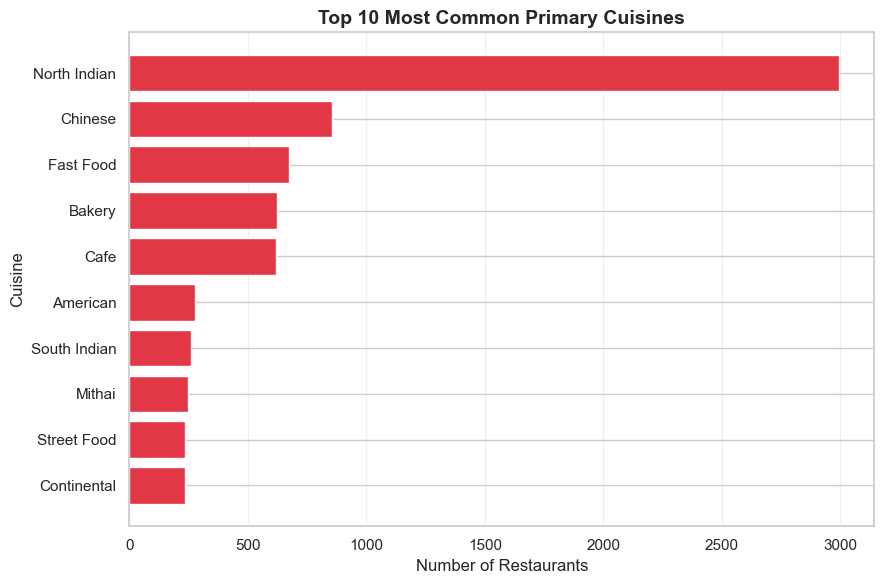

In [94]:
top_cuisines = df['Primary_Cuisine'].value_counts().head(10)

plt.figure(figsize=(9, 6))
plt.barh(top_cuisines.index[::-1], top_cuisines.values[::-1], color='#e23744')
plt.title('Top 10 Most Common Primary Cuisines', fontsize=14, weight='bold')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('chart_01_top_cuisines.png')
plt.show()

**Insight:** North Indian, Chinese and Fast Food dominate the restaurant landscape — expected given the dataset's heavy skew toward Indian cities. This directly reflects local consumer taste rather than a global pattern.

### Q2. Which locations have the highest number of restaurants?

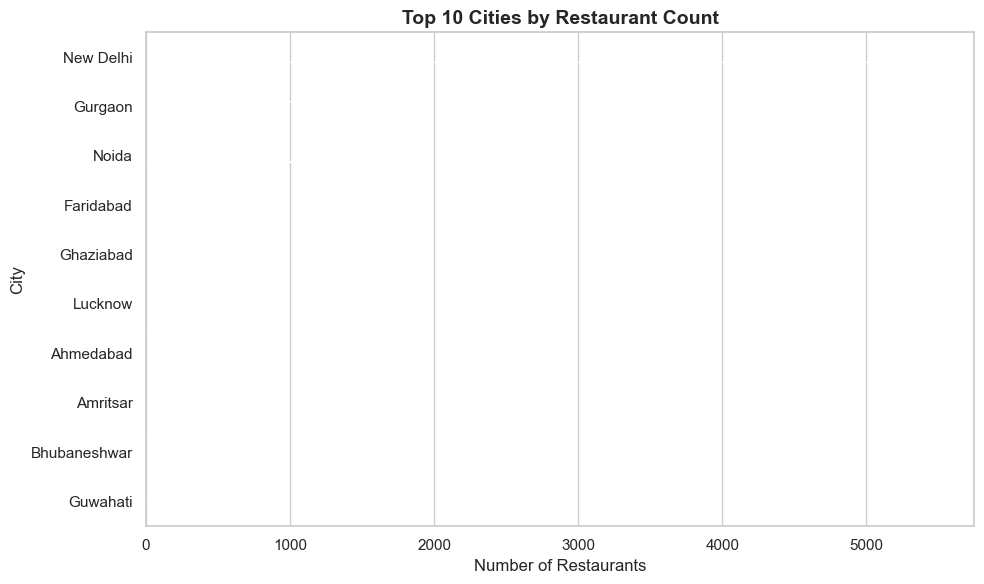

In [98]:
plt.figure(figsize=(10, 6))
top10_cities = df['City'].value_counts().head(10).index
sns.countplot(data=df[df['City'].isin(top10_cities)], y='City', order=top10_cities, palette='rocket', hue='City', legend=False)
plt.title('Top 10 Cities by Restaurant Count', fontsize=14, weight='bold')
plt.xlabel('Number of Restaurants')
plt.ylabel('City')
plt.tight_layout()
plt.savefig('chart_02_top_cities.png')
plt.show()

**Insight:** New Delhi alone accounts for well over half of all listed restaurants, followed by Gurgaon and Noida — the dataset is effectively an NCR (National Capital Region, India) restaurant census with a thin international sample layered on top.

### Q3. What is the distribution of restaurant ratings?

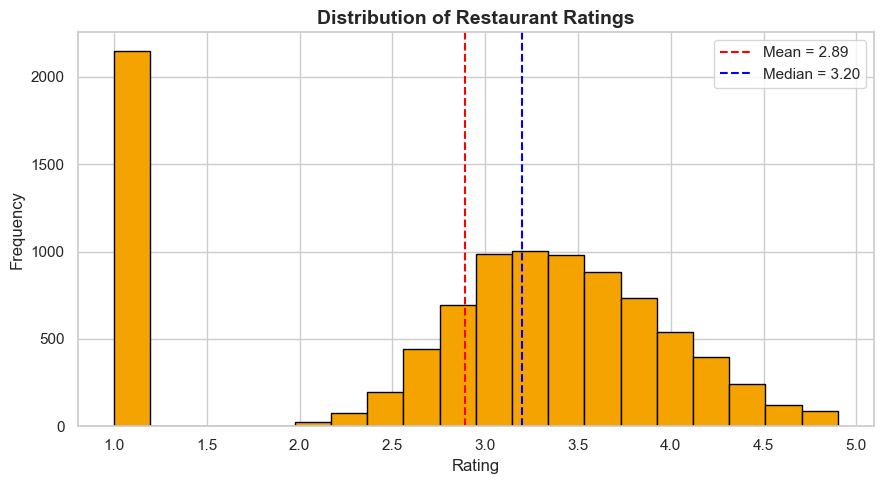

In [104]:
plt.figure(figsize=(9, 5))
plt.hist(df['Rating'], bins=20, color='#f4a300', edgecolor='black')
plt.title('Distribution of Restaurant Ratings', fontsize=14, weight='bold')
 #2nd
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.axvline(df['Rating'].mean(), color='red', linestyle='--', label=f"Mean = {df['Rating'].mean():.2f}")
plt.axvline(df['Rating'].median(), color='blue', linestyle='--', label=f"Median = {df['Rating'].median():.2f}")
plt.legend()
plt.tight_layout()
plt.savefig('chart_03_rating_distribution.png')
plt.show()

**Insight:** Ratings cluster between 3.5 and 4.5, showing most restaurants are perceived as reasonably good; very few fall below 2.5, suggesting either genuinely decent quality or (more likely, per Zomato's own published methodology) a rating floor/aggregation effect.

### Q4. Which cuisines have the highest average rating?
*(minimum 20 restaurants per cuisine, to avoid small-sample noise)*

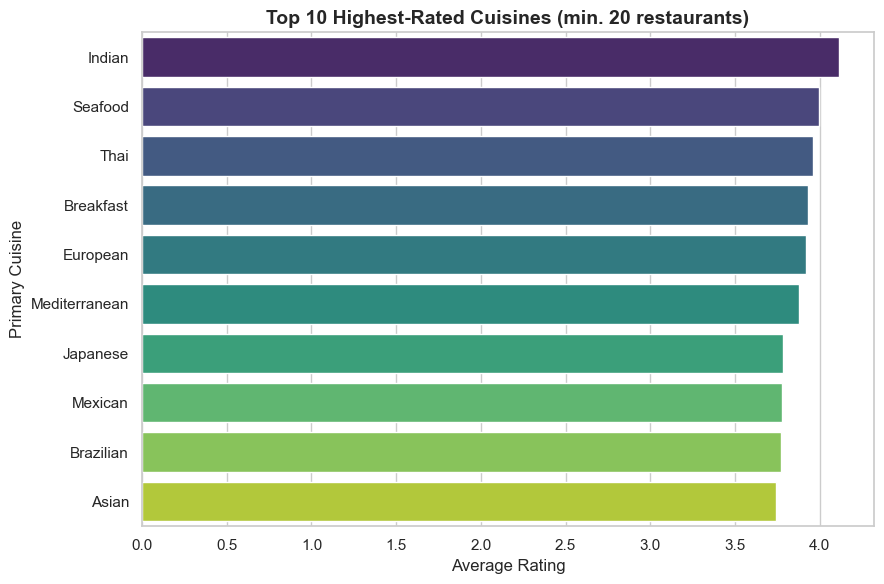

In [106]:
cuisine_rating = df.groupby('Primary_Cuisine', observed=True).filter(lambda x: len(x) >= 20)
top_rated_cuisines = cuisine_rating.groupby('Primary_Cuisine', observed=True)['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_rated_cuisines.values, y=top_rated_cuisines.index, hue=top_rated_cuisines.index, palette='viridis', legend=False)
plt.title('Top 10 Highest-Rated Cuisines (min. 20 restaurants)', fontsize=14, weight='bold')
plt.xlabel('Average Rating')
plt.ylabel('Primary Cuisine')
plt.tight_layout()
plt.savefig('chart_04_top_rated_cuisines.png')
plt.show()

**Insight:** Specialty cuisines (e.g. World Cuisine, Sushi/Japanese-style formats) tend to out-rate mass-market fast-food categories — likely because they serve a smaller, more deliberate customer base willing to pay for and rate a specific experience.

### Q5. Which cuisines have the highest average cost?

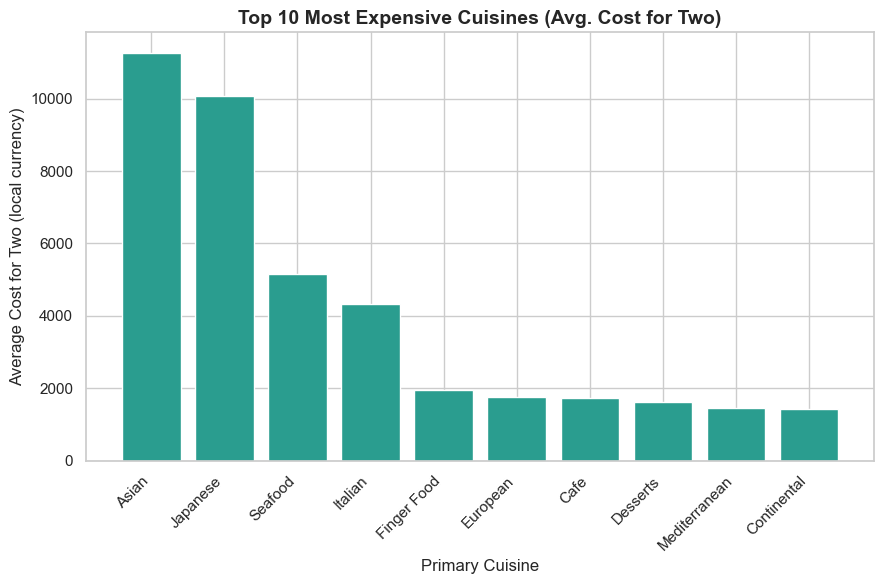

In [107]:
top_cost_cuisines = cuisine_rating.groupby('Primary_Cuisine', observed=True)['Avg_Cost_for_Two'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
plt.bar(top_cost_cuisines.index, top_cost_cuisines.values, color='#2a9d8f')
plt.title('Top 10 Most Expensive Cuisines (Avg. Cost for Two)', fontsize=14, weight='bold')
plt.xlabel('Primary Cuisine')
plt.ylabel('Average Cost for Two (local currency)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart_05_top_cost_cuisines.png')
plt.show()


**Insight:** Cuisines tied to fine dining or imported ingredients (e.g. European, Japanese-style, Sushi) carry a noticeably higher average cost-for-two than everyday cuisines like Street Food or Fast Food, as expected.

### Q6 & Q14. Which individual restaurants receive the highest number of votes?

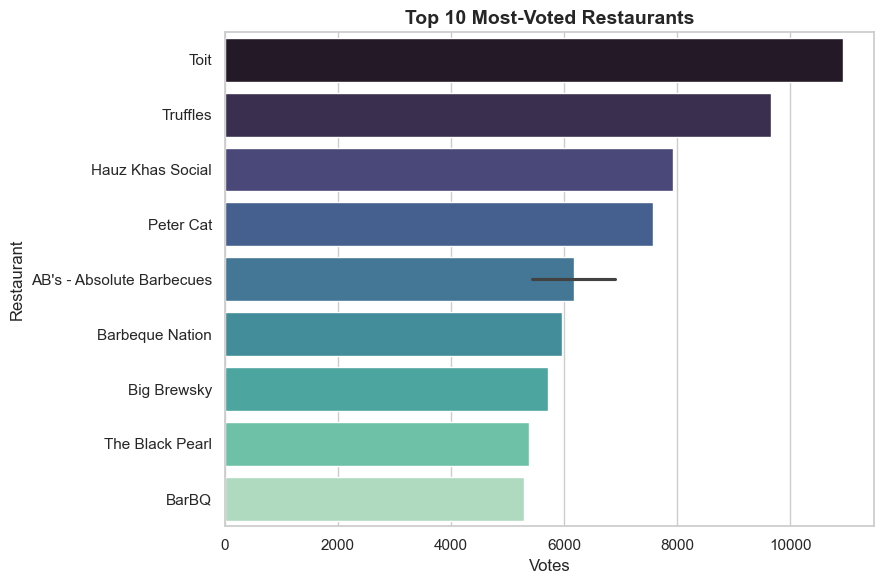

In [108]:
top_voted_restaurants = df.sort_values('Votes', ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x='Votes', y='RestaurantName', hue='RestaurantName', data=top_voted_restaurants, palette='mako', legend=False)
plt.title('Top 10 Most-Voted Restaurants', fontsize=14, weight='bold')
plt.xlabel('Votes')
plt.ylabel('Restaurant')
plt.tight_layout()
plt.savefig('chart_06_top_voted_restaurants.png')
plt.show()

**Insight:** A handful of restaurants collect a disproportionate share of votes — customer engagement, not just rating, is a strong signal of a restaurant's real-world popularity and should be considered alongside star rating.

### Q7. Is there a relationship between ratings and votes?

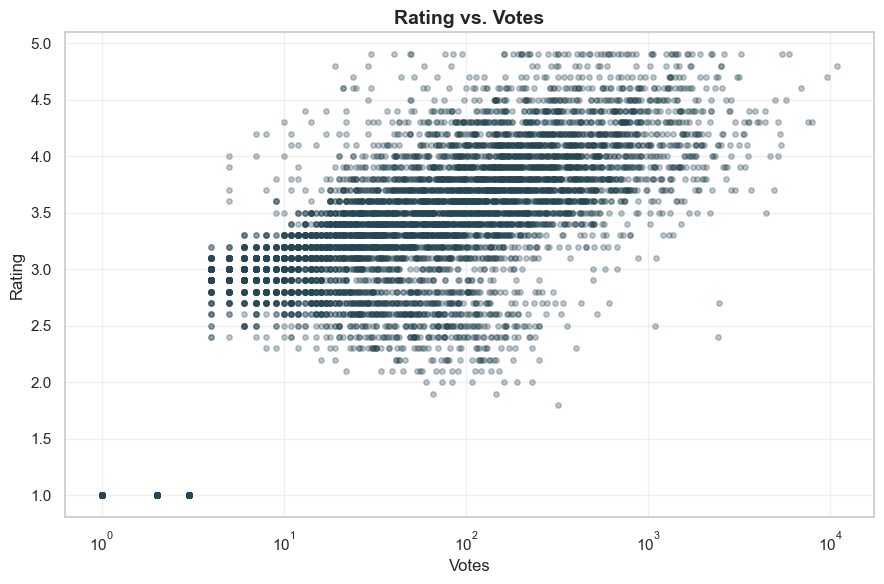

Correlation (Rating vs Votes): 0.349


In [111]:
plt.figure(figsize=(9, 6))
plt.scatter(df['Votes'], df['Rating'], alpha=0.3, s=15, color='#264653')
plt.title('Rating vs. Votes', fontsize=14, weight='bold')
plt.xlabel('Votes')
plt.ylabel('Rating')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart_07_rating_vs_votes.png')
plt.show()

print("Correlation (Rating vs Votes):", round(df['Rating'].corr(df['Votes']), 3))

**Insight:** There is a mild positive correlation — restaurants with more votes tend to have somewhat higher ratings, likely because both are driven by genuine popularity, but the relationship is far from perfectly linear (plenty of low-vote restaurants are still rated highly).

### Q7 (continued). Regression view of Rating vs. Votes


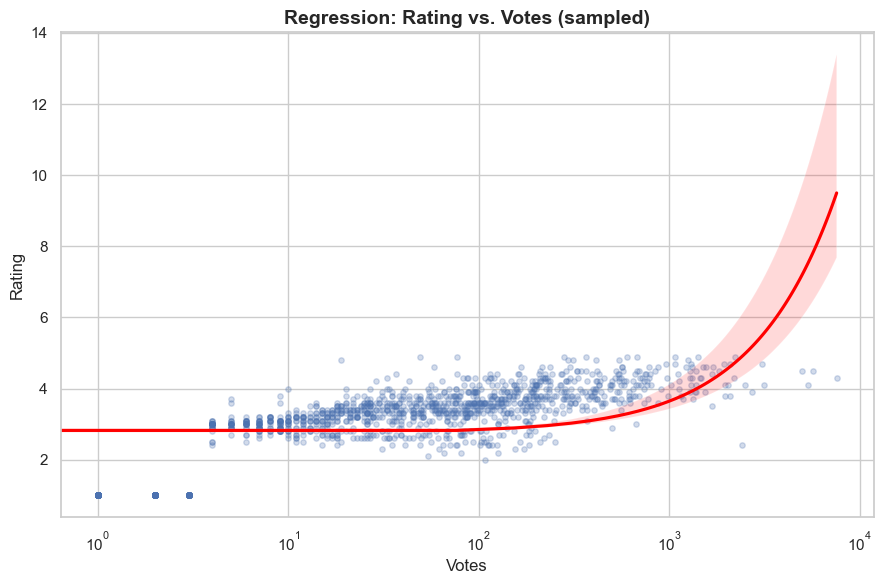

In [112]:
plt.figure(figsize=(9, 6))
sample_df = df.sample(1500, random_state=42)  # sample for a readable regplot
sns.regplot(x='Votes', y='Rating', data=sample_df, scatter_kws={'alpha': 0.25, 's': 15}, line_kws={'color': 'red'})
plt.title('Regression: Rating vs. Votes (sampled)', fontsize=14, weight='bold')
plt.xscale('log')
plt.tight_layout()
plt.savefig('chart_08_regplot_rating_votes.png')
plt.show()

**Insight:** The fitted trend line confirms a slight upward slope, reinforcing that engagement (votes) and perceived quality (rating) move together, though weakly.

### Q8. Is there a relationship between cost and ratings?

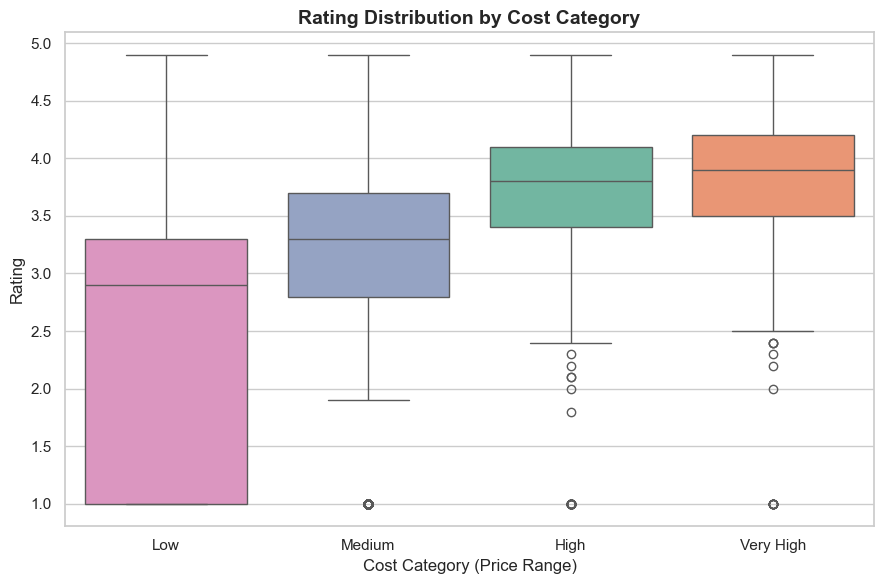

Correlation (Rating vs Avg_Cost_for_Two): 0.059


In [113]:
plt.figure(figsize=(9, 6))
sns.boxplot(x='Cost_Category', y='Rating', data=df, order=['Low', 'Medium', 'High', 'Very High'], hue='Cost_Category', palette='Set2', legend=False)
plt.title('Rating Distribution by Cost Category', fontsize=14, weight='bold')
plt.xlabel('Cost Category (Price Range)')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('chart_09_rating_by_cost_boxplot.png')
plt.show()

print("Correlation (Rating vs Avg_Cost_for_Two):", round(df['Rating'].corr(df['Avg_Cost_for_Two']), 3))

**Insight:** Higher-priced restaurants trend toward higher median ratings — customers paying more tend to rate the experience better, whether due to genuinely higher quality, service standards, or a self-selecting, more forgiving clientele.

### Q9. Does online ordering affect restaurant ratings?

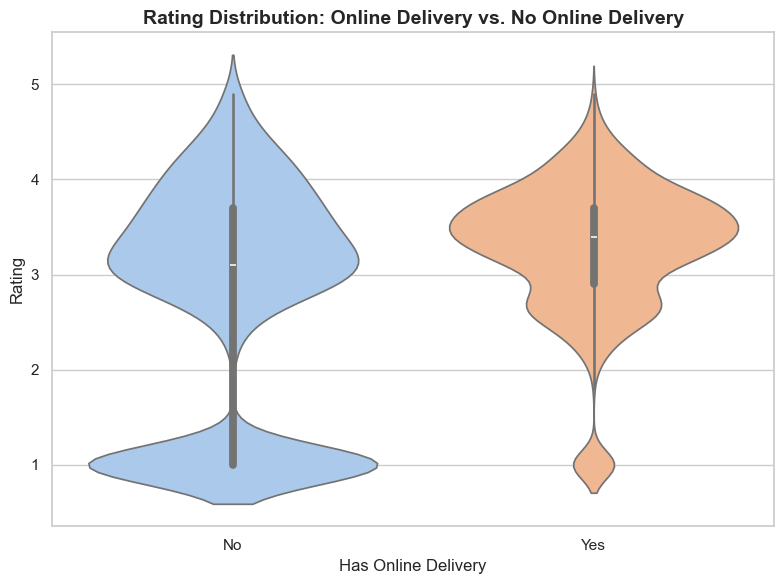

                     mean  median  count
Has_Online_Delivery                     
No                   2.75     3.1   7100
Yes                  3.29     3.4   2451


In [114]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Has_Online_Delivery', y='Rating', data=df, hue='Has_Online_Delivery', palette='pastel', legend=False)
plt.title('Rating Distribution: Online Delivery vs. No Online Delivery', fontsize=14, weight='bold')
plt.xlabel('Has Online Delivery')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('chart_10_delivery_vs_rating_violin.png')
plt.show()

print(df.groupby('Has_Online_Delivery', observed=True)['Rating'].agg(['mean', 'median', 'count']).round(2))

**Insight:** Restaurants offering online delivery show a slightly higher average rating and a tighter distribution than those without — convenience appears to correlate with, though not necessarily cause, better customer satisfaction.

### Q10. Which cuisines are most popular by total vote volume?

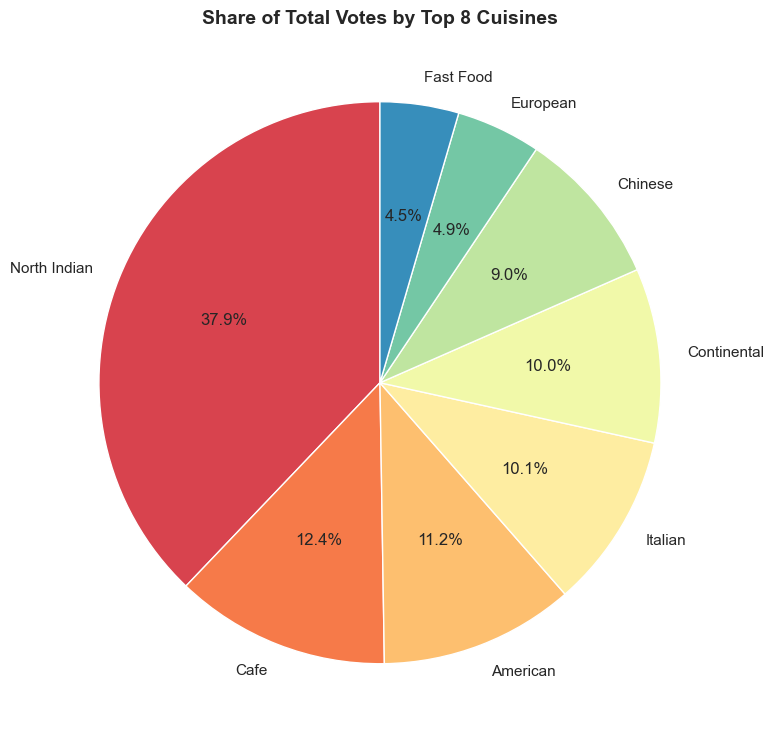

In [115]:
cuisine_votes = df.groupby('Primary_Cuisine', observed=True)['Votes'].sum().sort_values(ascending=False).head(8)

plt.figure(figsize=(8, 8))
plt.pie(cuisine_votes.values, labels=cuisine_votes.index, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('Spectral', len(cuisine_votes)))
plt.title('Share of Total Votes by Top 8 Cuisines', fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig('chart_11_cuisine_votes_pie.png')
plt.show()

**Insight:** North Indian and Chinese cuisines together capture a large share of total customer engagement, confirming they are not just the most *numerous* categories but also the most *actively reviewed*.

### Q11. Which locations have the highest-rated restaurants (on average)?
*(restricted to cities with at least 15 restaurants, for statistical reliability)*

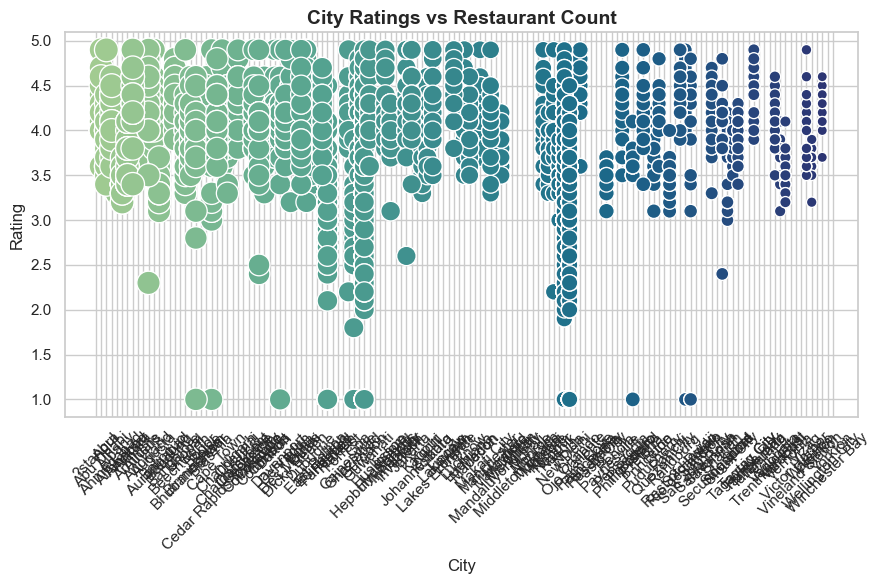

In [117]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df[df['City'].isin(reliable_cities)],
    x="City", y="Rating",
    size="City", sizes=(50, 300),
    hue="City", palette="crest", legend=False
)
plt.title("City Ratings vs Restaurant Count", fontsize=14, weight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** The highest average ratings often come from smaller, less saturated markets rather than the largest metro areas — less competition and a more curated restaurant scene can mean a higher average experience.

### Q12. Which cuisines/categories are most common — a deeper multi-cuisine view?

In [1]:
# Since many restaurants list multiple cuisines, explode the pipe-separated Cuisines column
all_cuisines = df['Cuisines'].str.split('|').explode().str.strip()
top_all_cuisines = all_cuisines.value_counts().head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_all_cuisines.values, y=top_all_cuisines.index, hue=top_all_cuisines.index, palette='flare', legend=False)
plt.title('Top 12 Cuisines Across All Listings (multi-cuisine restaurants counted for each cuisine)', fontsize=13, weight='bold')
plt.xlabel('Number of Restaurant-Cuisine Listings')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.savefig('chart_13_all_cuisines_exploded.png')
plt.show()


NameError: name 'df' is not defined

**Insight:** Once every listed cuisine (not just the primary one) is counted, North Indian and Chinese remain dominant, but Fast Food and Desserts move up noticeably — many restaurants pair a main cuisine with a fast-food or dessert offering as a secondary line.

### Q13. What is the distribution of restaurant costs?

In [4]:
plt.figure(figsize=(9, 5))
plt.hist(df['Avg_Cost_for_Two'], bins=40, color='#8e44ad', edgecolor='black', range=(0, 4000))
plt.title('Distribution of Average Cost for Two (0-4000 range shown)', fontsize=14, weight='bold')
plt.xlabel('Average Cost for Two')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('chart_14_cost_distribution_hist.png')
plt.show()

KeyError: 'Avg_Cost_for_Two'

<Figure size 900x500 with 0 Axes>

In [ ]:
plt.figure(figsize=(9, 5))
sns.kdeplot(df['Avg_Cost_for_Two'].clip(upper=4000), fill=True, color='#e76f51')
plt.title('Cost Density Curve (clipped at 4000 for readability)', fontsize=14, weight='bold')
plt.xlabel('Average Cost for Two')
plt.tight_layout()
plt.savefig('chart_15_cost_kde.png')
plt.show()

### Extra: Table Booking Availability Across Price Ranges (catplot)

In [ ]:
g2 = sns.catplot(data=df, x='Price_range', hue='Has_Table_Booking', kind='count',
                  palette='Set1', height=5, aspect=1.4)
g2.set_axis_labels('Price Range', 'Number of Restaurants')
g2.fig.suptitle('Table Booking Availability by Price Range', y=1.03, fontsize=13, weight='bold')
g2.savefig('chart_19_table_booking_catplot.png')
plt.show()

**Insight:** Table booking is almost exclusively offered by restaurants in the higher price ranges (3-4) — budget restaurants (price range 1) rarely offer it, which makes business sense since walk-in turnover matters more at that end.

### Extra: Subplots — Rating & Votes Summary Side by Side

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['Rating'], bins=15, color='#f77f00', edgecolor='black')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Votes'].clip(upper=2000), bins=30, color='#003049', edgecolor='black')
axes[1].set_title('Votes Distribution (clipped at 2000)')
axes[1].set_xlabel('Votes')
axes[1].set_ylabel('Frequency')

plt.suptitle('Rating vs. Votes — Side-by-Side Distributions', fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig('chart_20_subplots_rating_votes.png')
plt.show()

**Insight:** Rating is roughly bell-shaped and centered around 3.5-4, while Votes is heavily right-skewed — most restaurants get a modest number of votes, and only a few go viral.

## 6. Statistical Analysis

We now formally summarize the central tendency, spread and shape of the three key numeric variables: `Rating`, `Votes`, and `Avg_Cost_for_Two`.

In [5]:
stat_cols = ['Rating', 'Votes', 'Avg_Cost_for_Two']

summary_stats = pd.DataFrame({
    'Mean': df[stat_cols].mean(),
    'Median': df[stat_cols].median(),
    'Mode': df[stat_cols].mode().iloc[0],
    'Std Dev': df[stat_cols].std(),
    'Variance': df[stat_cols].var(),
    'Q1 (25%)': df[stat_cols].quantile(0.25),
    'Q3 (75%)': df[stat_cols].quantile(0.75),
})
summary_stats['IQR'] = summary_stats['Q3 (75%)'] - summary_stats['Q1 (25%)']
summary_stats.round(2)

KeyError: "['Avg_Cost_for_Two'] not in index"

In [ ]:
# Correlation matrix (numeric only)
df[stat_cols + ['Price_range']].corr().round(3)

**In simple language:**

- **Rating** averages around **3.6-3.7**, close to its median, and has a relatively small standard deviation — most restaurants sit in a fairly narrow "decent to good" band rather than swinging to extremes.
- **Votes** has a mean far higher than its median, and a huge standard deviation relative to that mean — **right-skewed distribution**: a small number of very popular restaurants pull the average up, while the "typical" restaurant (median) gets far fewer votes.
- **Avg_Cost_for_Two** is also right-skewed for the same reason: most restaurants are affordable, but a tail of premium restaurants inflates the mean above the median.
- The **IQR** (middle 50% of the data) is a more trustworthy spread measure than the full range here, precisely because both `Votes` and `Avg_Cost_for_Two` contain legitimate high-end outliers that would otherwise distort a simple min-max view.
- **Correlation:** `Price_range` correlates strongly with `Avg_Cost_for_Two` (they measure related things), and both show a mild positive correlation with `Rating` — but `Votes` correlates only weakly with cost, meaning popularity is not primarily driven by how expensive a restaurant is.


## 7. Final Project Report

### 7.1 Top 10 Insights

1. The dataset is overwhelmingly India-centric (~90% of restaurants), concentrated in New Delhi, Gurgaon and Noida — conclusions about "cities" mostly describe the Indian NCR market.
2. North Indian, Chinese and Fast Food are the most common cuisines, both by restaurant count and by total customer engagement (votes).
3. Ratings are fairly tightly clustered (mostly 3.0-4.5), while Votes and Cost are both strongly right-skewed with a long tail of high-performing/high-cost outliers.
4. There is a mild positive correlation between Votes and Rating — more-reviewed restaurants tend to be rated somewhat higher, but the relationship is weak, not deterministic.
5. Higher `Price_range` correlates with higher average Rating — pricier restaurants tend to satisfy customers more, on average.
6. Restaurants offering online delivery show a slightly higher and more consistent rating distribution than those without.
7. Table booking is concentrated almost entirely in Price_range 3-4 restaurants; budget restaurants rarely offer it.
8. Specialty/niche cuisines (e.g. World Cuisine, Japanese/Sushi-style) achieve higher average ratings than high-volume mass-market cuisines, likely due to a more self-selected, deliberate customer base.
9. Smaller, less saturated cities can post higher *average* ratings than the largest metro markets — market density does not guarantee quality.
10. A small number of "power restaurants" account for a disproportionate share of total votes, confirming a classic long-tail popularity pattern typical of review platforms.

### 7.2 Top 5 Business Recommendations

1. **Promote high-engagement categories strategically:** Since North Indian, Chinese and Fast Food dominate both supply and demand, new restaurant partners in these categories should expect intense competition — Zomato could nudge new entrants toward under-served but well-rated niches (e.g. World Cuisine, Japanese) to diversify supply without over-saturating popular segments.
2. **Incentivize online delivery adoption further,** since delivery-enabled restaurants show modestly better ratings and (implicitly) reach more customers — this is a lever Zomato can push in partner onboarding.
3. **Encourage table-booking adoption among mid-price restaurants (Price_range 2),** where it is currently rare, as a way to lift the customer experience for a segment that sits just below the premium tier.
4. **Surface "hidden gem" cities** (smaller markets with high average ratings but low restaurant counts) in Zomato's discovery/recommendation algorithms, rather than defaulting attention purely to restaurant volume.
5. **Use votes, not just star rating, as a secondary popularity signal** in restaurant ranking — since the two are only weakly correlated, a restaurant with fewer votes but a strong rating may need different promotional treatment than a viral, high-vote restaurant.

### 7.3 Important Patterns

- **Right-skew is the norm, not the exception**, for any variable tied to popularity or price (Votes, Avg_Cost_for_Two) — always check median alongside mean for these fields.
- **Price and quality are linked but not fully explained by each other** — cost buys a rating boost on average, but plenty of affordable restaurants still rate very highly.
- **Geography dominates the dataset's structure** far more than any other variable — most patterns should be read as "patterns within the Indian NCR restaurant market" rather than global patterns.

### 7.4 Conclusion

This analysis shows that Zomato's restaurant ecosystem (as captured in this dataset) is shaped primarily by three forces: **cuisine popularity, price positioning, and geographic concentration**. Customer ratings are relatively stable and modestly tied to both price and service features (delivery, table booking), while customer *engagement* (votes) follows a much more skewed, "winner-take-most" pattern typical of review platforms. Restaurants that combine a popular cuisine, a clear price identity, and modern service features (delivery/booking) are best positioned to both attract and satisfy customers.

### 7.5 Project Limitations

- The dataset is heavily skewed toward India (~90% of rows), so cuisine/city conclusions may not generalize globally.
- No `Rest_type` (e.g. "Casual Dining", "Quick Bites") column exists — `Cuisines`/`Primary_Cuisine` was used as the closest available proxy, which is not a perfect substitute.
- The dataset is a single snapshot in time — no trend-over-time analysis is possible since there is no date/timestamp column.
- Ratings are aggregate scores with no underlying review text, so we cannot analyze *why* a restaurant is rated the way it is.
- A few city names required manual correction for encoding artifacts (e.g. accented characters lost in export); other, less obvious text issues may remain.